
--- Processing Stage 1: Cross-Entropy Baseline ---


Extracting Test Embeddings: 100%|██████████| 11/11 [02:01<00:00, 11.08s/it]


Running t-SNE reduction for 1294 test samples...

--- Processing Stage 2: ArcFace + SupCon (Refined) ---


Extracting Test Embeddings: 100%|██████████| 11/11 [02:28<00:00, 13.47s/it]


Running t-SNE reduction for 1294 test samples...


/var/folders/__/t28g3nwn2vg90t4kgqdbghm40000gn/T/ipykernel_70749/1612163479.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('turbo', 90)



Visualizations (Test Set Only) saved: tsne_90class_test_set_comparison.png/pdf


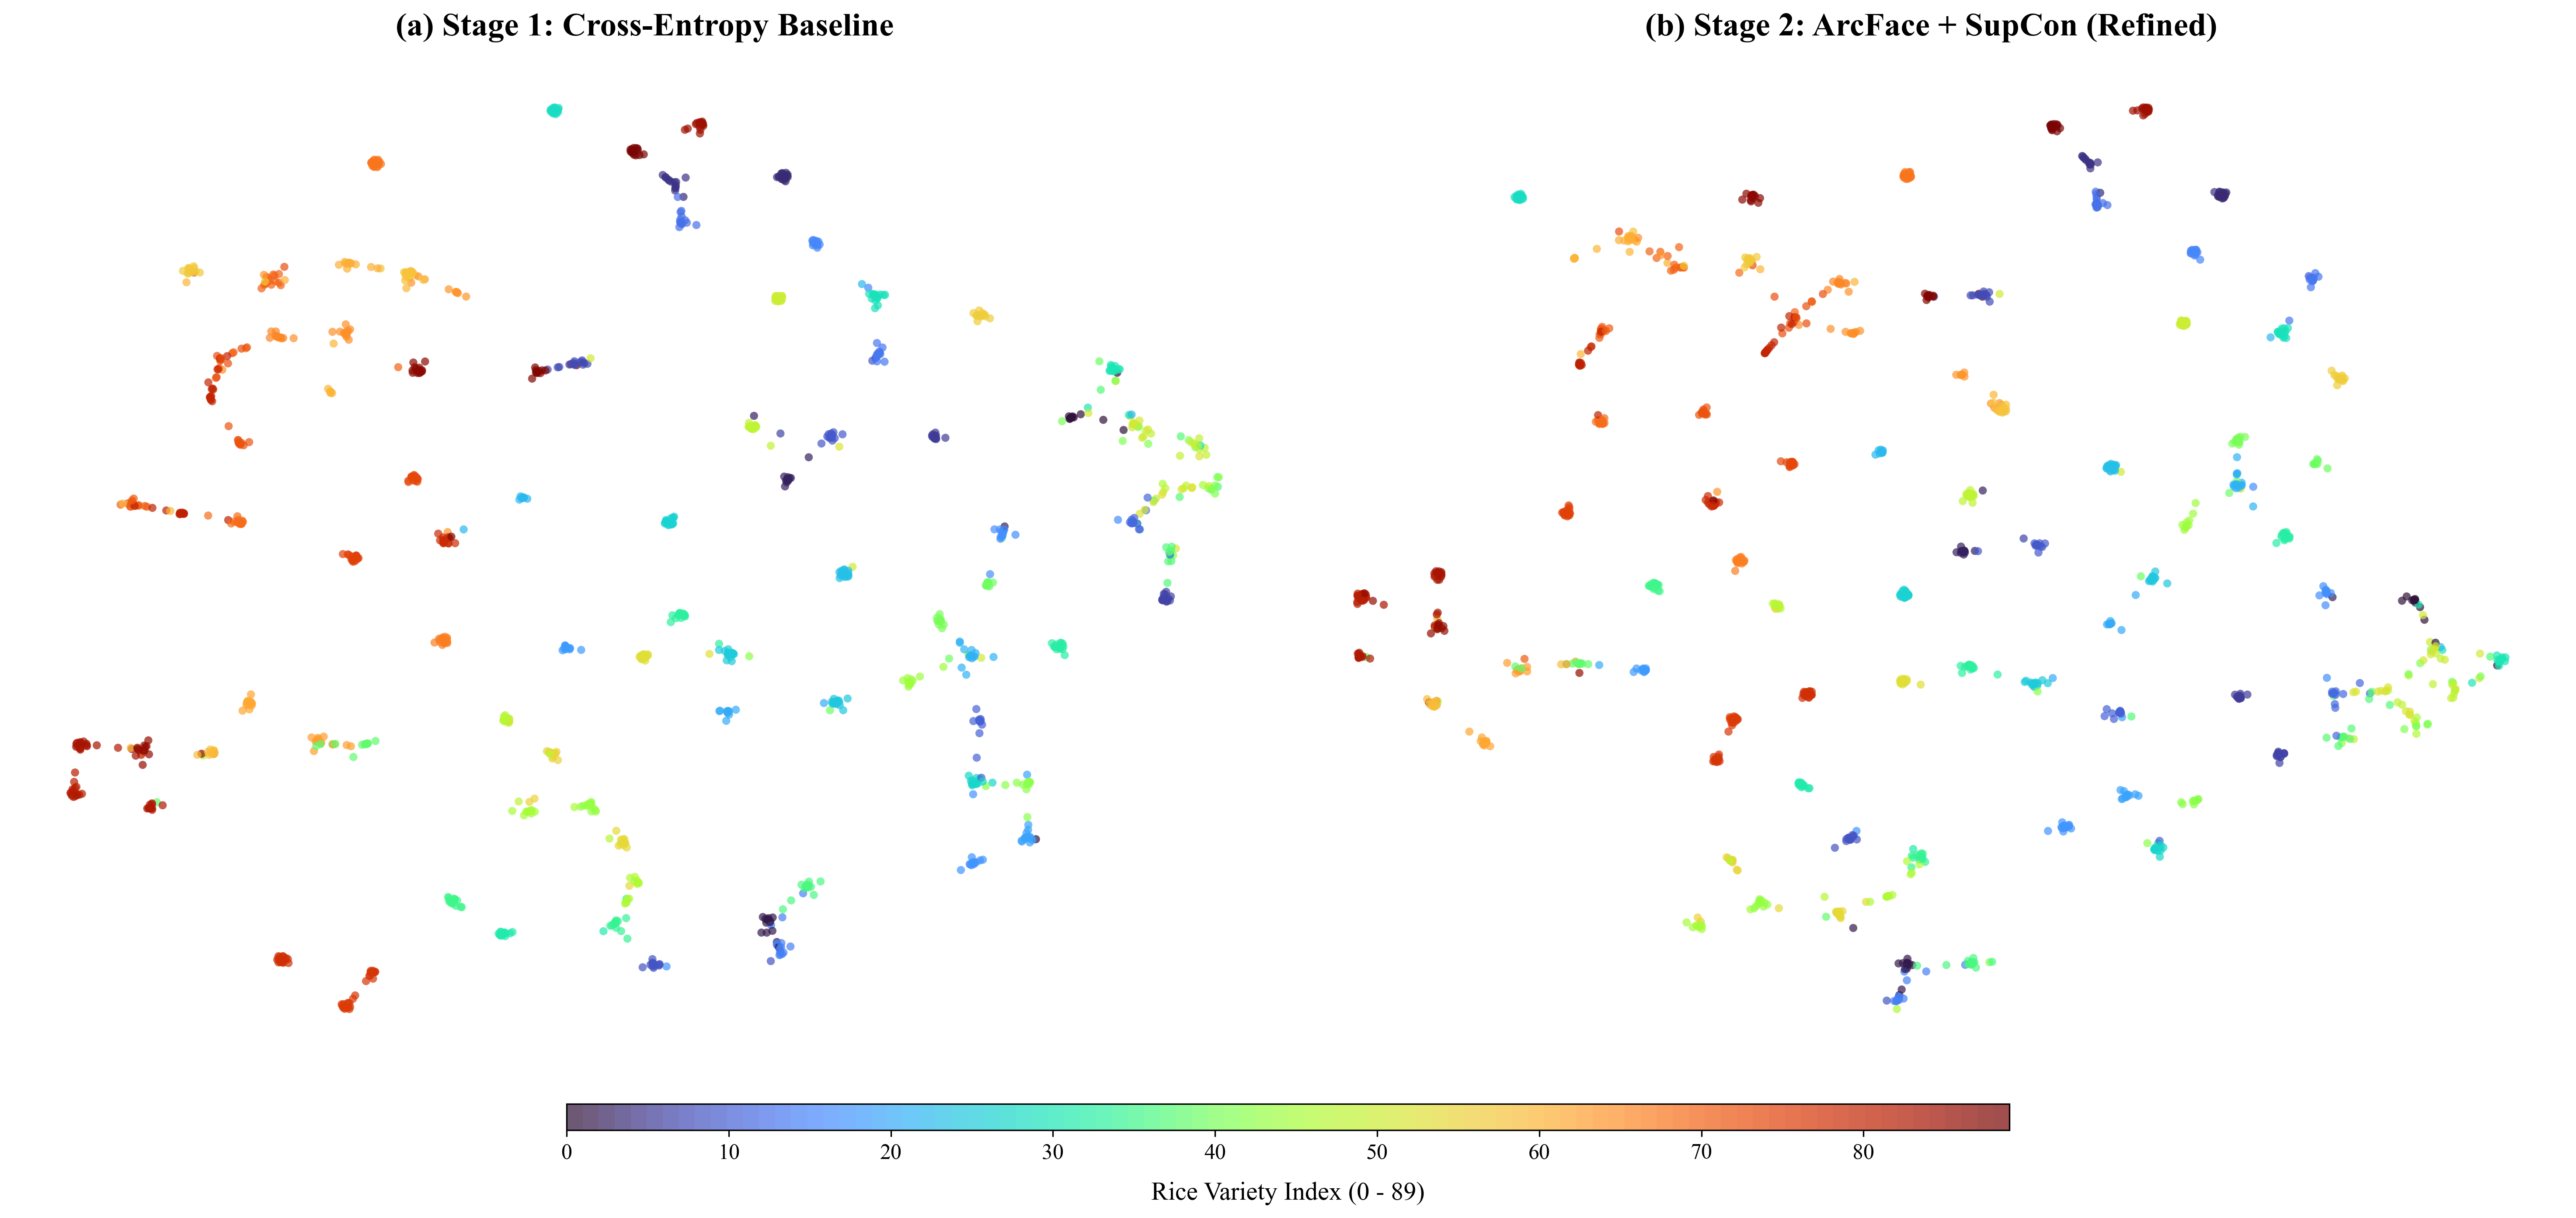

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader
from tqdm import tqdm

from HSI_modality_training.hsi_training import (
    SpectralQuadNet, ModelEMA, RiceSeedDataset, 
    _load_data_mmap, _load_wavelengths_to_gpu, 
    build_splits, CONFIG, load_ckpt
)

def get_test_embeddings(model, device):
    """Extracts embeddings specifically for the test set samples."""
    model.eval()
    
    # 1. Get the dataset splits and isolate the test indices[cite: 10]
    _, _, _, test_idx = build_splits()
    
    # 2. Create a DataLoader using only the test indices
    test_loader = DataLoader(
        RiceSeedDataset(test_idx, aug_strength="none"), 
        batch_size=128, 
        shuffle=False, 
        num_workers=0
    )
    
    embeddings, labels = [], []
    with torch.no_grad():
        for x, y in tqdm(test_loader, desc="Extracting Test Embeddings"):
            x = x.to(device)
            # return_embed=True returns (logits, normalized_emb)[cite: 10]
            _, emb = model(x, return_embed=True)
            embeddings.append(emb.cpu().numpy())
            labels.append(y.numpy())
            
    return np.vstack(embeddings), np.concatenate(labels)

def generate_final_visualization():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Initialize Data and Model
    _load_data_mmap(CONFIG["patches_data"], CONFIG["labels_path"])
    _load_wavelengths_to_gpu(CONFIG["wavelength_path"], device)
    
    model = SpectralQuadNet(num_classes=90, num_bands=40).to(device)
    ema = ModelEMA(model)
    
    stages = [
        ("Stage 1: Cross-Entropy Baseline", "best_stage1.pth"),
        ("Stage 2: ArcFace + SupCon (Refined)", "best_stage2.pth")
    ]
    
    results = {}
    
    # Extract and Reduce
    for label, ckpt_name in stages:
        ckpt_path = os.path.join(CONFIG["output_dir"], ckpt_name)
        print(f"\n--- Processing {label} ---")
        
        load_ckpt(ckpt_path, model, ema, device)
        # Use the updated function to get test-only embeddings[cite: 10]
        emb, targets = get_test_embeddings(ema.shadow, device)
        
        print(f"Running t-SNE reduction for {len(emb)} test samples...")
        tsne = TSNE(
            n_components=2, 
            perplexity=30, # Slightly lower perplexity is often better for smaller test sets
            random_state=42, 
            init='pca', 
            learning_rate='auto',
            n_jobs=-1
        )
        emb_2d = tsne.fit_transform(emb)
        results[label] = (emb_2d, targets)

    # Publication-Quality Plotting
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 12,
        "axes.titlesize": 18,
        "figure.dpi": 300
    })

    fig, axes = plt.subplots(1, 2, figsize=(22, 10))
    cmap = plt.cm.get_cmap('turbo', 90) 
    panel_labels = ["(a)", "(b)"]

    for i, (label, (emb_2d, targets)) in enumerate(results.items()):
        ax = axes[i]
        scatter = ax.scatter(
            emb_2d[:, 0], emb_2d[:, 1], 
            c=targets, 
            cmap=cmap, 
            s=20, # Slightly larger points for better visibility on the test set
            alpha=0.7, 
            edgecolors='none'
        )
        ax.set_title(f"{panel_labels[i]} {label}", pad=15, fontweight='bold')
        ax.axis('off')

    plt.tight_layout(rect=[0.05, 0.12, 0.95, 0.95])
    cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
    cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Rice Variety Index (0 - 89)', fontsize=14, labelpad=10)
    
    plt.savefig('tsne_90class_test_set_comparison.png', dpi=600, bbox_inches='tight')
    plt.savefig('tsne_90class_test_set_comparison.pdf', bbox_inches='tight')
    print("\nVisualizations (Test Set Only) saved: tsne_90class_test_set_comparison.png/pdf")
    plt.show()

if __name__ == "__main__":
    generate_final_visualization()